# Stock Market Analysis Tool


#### This project uses Python to analyse historical stock market data (specifically from 2024 to 2025). The aim is to compare the performance, risk and relationships between several publicly traded companies using financial metrics such as daily returns, volatility and correlation. To conclude the project, a hypothetical portfolio is constructed using the selected companies and analysed to demonstrate the concept of diversification.
#### By analysing historical market data, this project demonstrates how quantitative techniques can be used to evaluate investment opportunities and support financial decision-making. It highlights the trade-off between risk and return, examines how different stocks move relative to one another, and shows how portfolio construction can reduce overall risk through diversification. In addition, the project demonstrates practical experience using Python, Pandas, NumPy and Matplotlib to collect, process, analyse and visualise financial data.

## Import Libraries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install yfinance
import yfinance as yf

## Load Stock Data


#### This section is where the historic stock data is downloaded from Yahoo Finance, which will be analysed in further sections

In [10]:
apple = yf.download(
    "AAPL",
    start="2024-01-01",
    end="2025-01-01"
)

apple 

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.562180,186.330843,181.831767,185.055273,82488700
2024-01-03,182.187744,183.799505,181.376915,182.158081,58414500
2024-01-04,179.873947,181.040733,178.855477,180.111251,71983600
2024-01-05,179.152115,180.714432,178.153425,179.953062,62379700
2024-01-08,183.483063,183.522623,179.468508,180.051901,59144500
...,...,...,...,...,...
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700
2024-12-26,257.375610,258.448771,255.994450,256.550893,27237100


In [11]:
apple.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.562180,186.330843,181.831767,185.055273,82488700
2024-01-03,182.187744,183.799505,181.376915,182.158081,58414500
2024-01-04,179.873947,181.040733,178.855477,180.111251,71983600
2024-01-05,179.152115,180.714432,178.153425,179.953062,62379700
2024-01-08,183.483063,183.522623,179.468508,180.051901,59144500


In [12]:
apple.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2024-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   252 non-null    float64
 1   (High, AAPL)    252 non-null    float64
 2   (Low, AAPL)     252 non-null    float64
 3   (Open, AAPL)    252 non-null    float64
 4   (Volume, AAPL)  252 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [13]:
stocks

Price            Close                                            High  \
Ticker            AAPL         JPM        MSFT        TSLA        AAPL   
Date                                                                     
2024-01-02  183.562180  162.278290  363.801575  248.419998  186.330843   
2024-01-03  182.187744  161.570984  363.536652  238.449997  183.799505   
2024-01-04  179.873947  162.643234  360.927368  237.929993  181.040733   
2024-01-05  179.152115  163.459244  360.740997  237.490005  180.714432   
2024-01-08  183.483063  163.222015  367.548676  240.449997  183.522623   
...                ...         ...         ...         ...         ...   
2024-12-24  256.560822  233.964584  434.179321  462.279999  256.570737   
2024-12-26  257.375610  234.766006  432.973694  454.130005  258.448771   
2024-12-27  253.967392  232.863876  425.482544  431.660004  257.057664   
2024-12-30  250.598938  231.077576  419.849365  417.410004  251.890688   
2024-12-31  248.830215  231.454163  416.558411  403.839996  251.672059   

Price                                                  Low              \
Ticker             JPM        MSFT        TSLA        AAPL         JPM   
Date                                                                     
2024-01-02  162.363160  368.735707  251.250000  181.831767  159.288855   
2024-01-03  162.240534  366.145958  245.679993  181.376915  160.665659   
2024-01-04  164.484015  365.989026  242.699997  178.855477  161.817721   
2024-01-05  164.512473  364.968850  240.119995  178.153425  162.700157   
2024-01-08  163.544623  368.048965  241.250000  179.468508  160.821414   
...                ...         ...         ...         ...         ...   
2024-12-24  234.138393  434.446175  462.779999  253.669277  230.836183   
2024-12-26  234.881869  435.770533  465.329987  255.994450  232.496937   
2024-12-27  235.007419  430.117562  450.000000  251.453455  231.772790   
2024-12-30  232.545215  422.537478  427.000000  249.158146  228.943684   
2024-12-31  233.124576  421.727106  427.929993  247.846495  230.797575   

Price                                     Open                          \
Ticker            MSFT        TSLA        AAPL         JPM        MSFT   
Date                                                                     
2024-01-02  359.779711  244.410004  185.055273  159.458596  366.734579   
2024-01-03  361.486489  236.320007  182.158081  162.070794  361.976959   
2024-01-04  360.172055  237.729996  180.111251  161.912612  363.605347   
2024-01-05  359.514821  234.899994  179.953062  162.700157  361.937746   
2024-01-08  361.976940  235.300003  180.051901  163.222015  362.261391   
...                ...         ...         ...         ...         ...   
2024-12-24  429.099598  435.140015  253.868019  231.183770  429.554196   
2024-12-26  431.511064  451.019989  256.550893  233.114894  433.932323   
2024-12-27  421.351557  426.500000  256.193162  234.360496  429.504835   
2024-12-30  416.953723  415.750000  250.628746  230.546515  421.064956   
2024-12-31  415.728262  402.540009  250.837396  231.782449  421.104487   

Price                     Volume                                 
Ticker            TSLA      AAPL       JPM      MSFT       TSLA  
Date                                                             
2024-01-02  250.080002  82488700   9977400  25258600  104654200  
2024-01-03  244.979996  58414500   9852300  23083500  121082600  
2024-01-04  239.250000  71983600  11972500  20901500  102629300  
2024-01-05  236.860001  62379700  10066000  21004600   92488900  
2024-01-08  236.139999  59144500  11229900  23134000   85166600  
...                ...       ...       ...       ...        ...  
2024-12-24  435.899994  23234700   3729100   7164500   59551800  
2024-12-26  465.160004  27237100   4451800   8194200   76366400  
2024-12-27  449.519989  42355300   5730200  18117700   82666800  
2024-12-30  419.399994  35557500   5723800  13158700   64941000  
2024-12-31  423.790009  3948070

## Calculate Returns

In [14]:
apple["Daily Return %"] = apple["Close", "AAPL"].pct_change()*100
apple.head()

Price,Close,High,Low,Open,Volume,Daily Return %
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2024-01-02,183.562180,186.330843,181.831767,185.055273,82488700,NaN
2024-01-03,182.187744,183.799505,181.376915,182.158081,58414500,-0.748757
2024-01-04,179.873947,181.040733,178.855477,180.111251,71983600,-1.270007
2024-01-05,179.152115,180.714432,178.153425,179.953062,62379700,-0.401299
2024-01-08,183.483063,183.522623,179.468508,180.051901,59144500,2.417470


In [15]:
print(apple.columns)

MultiIndex([(         'Close', 'AAPL'),
            (          'High', 'AAPL'),
            (           'Low', 'AAPL'),
            (          'Open', 'AAPL'),
            (        'Volume', 'AAPL'),
            ('Daily Return %',     '')],
           names=['Price', 'Ticker'])


## Single Stock Analysis (Apple)

#### This section analyses one specific stock using historic data finding information such as daily returns and total return, as well as finding the companies best and worst days. This provides a basic information of one company and demonstrates wha can be found with Python, before it is compared to other companies

In [16]:
print(
    "Average Daily Return:",
    apple["Daily Return %"].mean()
)

best_day = apple.loc[
    apple["Daily Return %"].idxmax()
]

best_day

Average Daily Return: 0.13115515691492993


Price           Ticker
Close           AAPL      2.053710e+02
High            AAPL      2.053809e+02
Low             AAPL      1.919671e+02
Open            AAPL      1.919869e+02
Volume          AAPL      1.723733e+08
Daily Return %            7.264925e+00
Name: 2024-06-11 00:00:00, dtype: float64

In [17]:
worst_day = apple.loc[
    apple["Daily Return %"].idxmin()
]

worst_day

Price           Ticker
Close           AAPL      2.074728e+02
High            AAPL      2.116664e+02
Low             AAPL      1.943167e+02
Open            AAPL      1.973802e+02
Volume          AAPL      1.195486e+08
Daily Return %           -4.816702e+00
Name: 2024-08-05 00:00:00, dtype: float64

In [18]:
initial_price = apple[("Close", "AAPL")].iloc[0]
final_price = apple[("Close", "AAPL")].iloc[-1]

total_return = ((final_price - initial_price) / initial_price) * 100
print("Total Return:", round(total_return, 2), "%")

Total Return: 35.56 %


<function matplotlib.pyplot.show(close=None, block=None)>

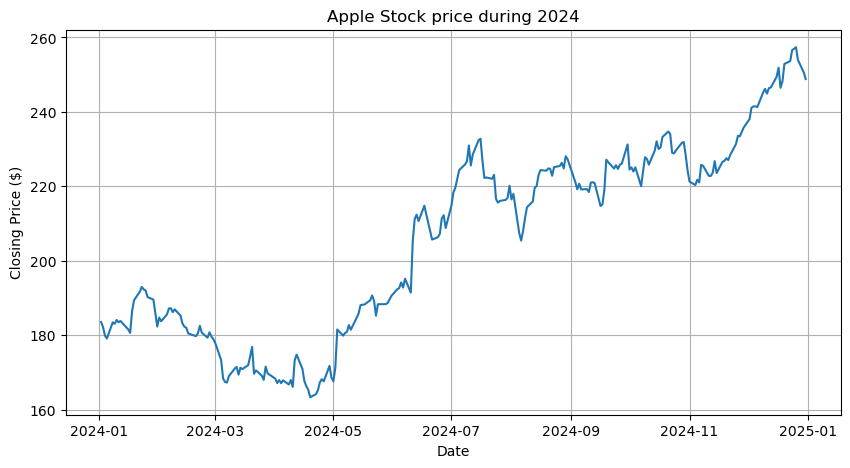

In [36]:
plt.figure(figsize=(10,5))

plt.plot(
    apple.index,
    apple[("Close", "AAPL")]
)



plt.title("Apple Stock price during 2024")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")

plt.grid(True)
plt.show

## Multi-Stock Comparison

#### This section of the project compares mutliple companies using common financial metrics such as daily returns, average returns, volatility etc. This allows for investors to gain an idea of the risk to return of different stocks, as well as summarises large pieces of data of different companies and compares the important statistics between them (eg their daily return). The 4 companies used are Apple, Tesla, Microsoft and Jp Morgan.

In [19]:
stocks = yf.download(
    ["AAPL", "MSFT", "TSLA", "JPM"],
    start="2024-01-01",
    end="2025-01-01"
)
stocks

[*********************100%***********************]  4 of 4 completed


Price            Close                                            High  \
Ticker            AAPL         JPM        MSFT        TSLA        AAPL   
Date                                                                     
2024-01-02  183.562180  162.278290  363.801575  248.419998  186.330843   
2024-01-03  182.187744  161.570984  363.536652  238.449997  183.799505   
2024-01-04  179.873947  162.643234  360.927368  237.929993  181.040733   
2024-01-05  179.152115  163.459244  360.740997  237.490005  180.714432   
2024-01-08  183.483063  163.222015  367.548676  240.449997  183.522623   
...                ...         ...         ...         ...         ...   
2024-12-24  256.560822  233.964584  434.179321  462.279999  256.570737   
2024-12-26  257.375610  234.766006  432.973694  454.130005  258.448771   
2024-12-27  253.967392  232.863876  425.482544  431.660004  257.057664   
2024-12-30  250.598938  231.077576  419.849365  417.410004  251.890688   
2024-12-31  248.830215  231.454163  416.558411  403.839996  251.672059   

Price                                                  Low              \
Ticker             JPM        MSFT        TSLA        AAPL         JPM   
Date                                                                     
2024-01-02  162.363160  368.735707  251.250000  181.831767  159.288855   
2024-01-03  162.240534  366.145958  245.679993  181.376915  160.665659   
2024-01-04  164.484015  365.989026  242.699997  178.855477  161.817721   
2024-01-05  164.512473  364.968850  240.119995  178.153425  162.700157   
2024-01-08  163.544623  368.048965  241.250000  179.468508  160.821414   
...                ...         ...         ...         ...         ...   
2024-12-24  234.138393  434.446175  462.779999  253.669277  230.836183   
2024-12-26  234.881869  435.770533  465.329987  255.994450  232.496937   
2024-12-27  235.007419  430.117562  450.000000  251.453455  231.772790   
2024-12-30  232.545215  422.537478  427.000000  249.158146  228.943684   
2024-12-31  233.124576  421.727106  427.929993  247.846495  230.797575   

Price                                     Open                          \
Ticker            MSFT        TSLA        AAPL         JPM        MSFT   
Date                                                                     
2024-01-02  359.779711  244.410004  185.055273  159.458596  366.734579   
2024-01-03  361.486489  236.320007  182.158081  162.070794  361.976959   
2024-01-04  360.172055  237.729996  180.111251  161.912612  363.605347   
2024-01-05  359.514821  234.899994  179.953062  162.700157  361.937746   
2024-01-08  361.976940  235.300003  180.051901  163.222015  362.261391   
...                ...         ...         ...         ...         ...   
2024-12-24  429.099598  435.140015  253.868019  231.183770  429.554196   
2024-12-26  431.511064  451.019989  256.550893  233.114894  433.932323   
2024-12-27  421.351557  426.500000  256.193162  234.360496  429.504835   
2024-12-30  416.953723  415.750000  250.628746  230.546515  421.064956   
2024-12-31  415.728262  402.540009  250.837396  231.782449  421.104487   

Price                     Volume                                 
Ticker            TSLA      AAPL       JPM      MSFT       TSLA  
Date                                                             
2024-01-02  250.080002  82488700   9977400  25258600  104654200  
2024-01-03  244.979996  58414500   9852300  23083500  121082600  
2024-01-04  239.250000  71983600  11972500  20901500  102629300  
2024-01-05  236.860001  62379700  10066000  21004600   92488900  
2024-01-08  236.139999  59144500  11229900  23134000   85166600  
...                ...       ...       ...       ...        ...  
2024-12-24  435.899994  23234700   3729100   7164500   59551800  
2024-12-26  465.160004  27237100   4451800   8194200   76366400  
2024-12-27  449.519989  42355300   5730200  18117700   82666800  
2024-12-30  419.399994  35557500   5723800  13158700   64941000  
2024-12-31  423.790009  3948070

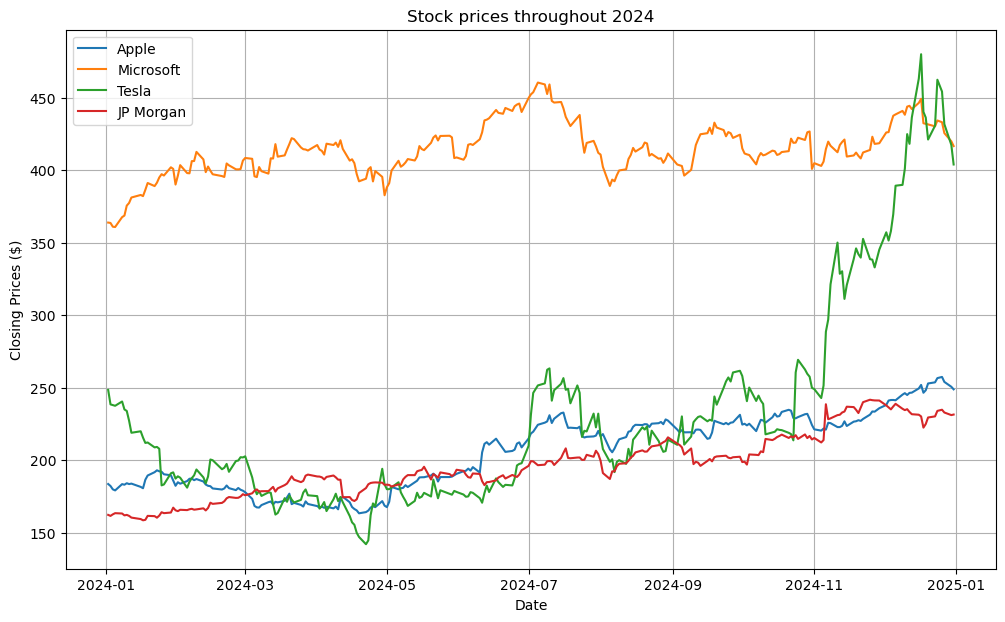

In [37]:
plt.figure(figsize=(12,7))
plt.plot(stocks.index, stocks[("Close", "AAPL")], label="Apple")
plt.plot(stocks.index, stocks[("Close", "MSFT")], label="Microsoft")
plt.plot(stocks.index, stocks[("Close", "TSLA")], label="Tesla")
plt.plot(stocks.index, stocks[("Close", "JPM")], label="JP Morgan")

plt.title("Stock prices throughout 2024")
plt.xlabel("Date")
plt.ylabel("Closing Prices ($)")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
daily_returns = stocks["Close"].pct_change() * 100
daily_returns.head()

Ticker,AAPL,JPM,MSFT,TSLA
Date,,,,
2024-01-02,NaN,NaN,NaN,NaN
2024-01-03,-0.748757,-0.435860,-0.072821,-4.013365
2024-01-04,-1.270007,0.663640,-0.717750,-0.218077
2024-01-05,-0.401299,0.501717,-0.051637,-0.184923
2024-01-08,2.417470,-0.145130,1.887137,1.246365


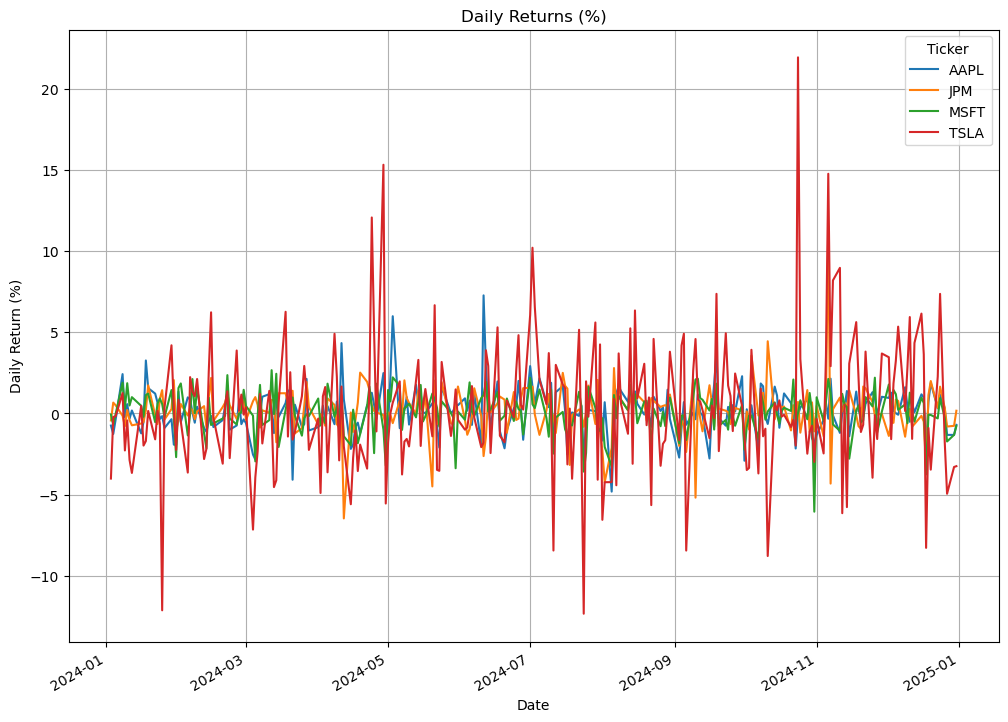

In [38]:
daily_returns.plot(figsize=(12,9))
plt.title("Daily Returns (%)")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.grid(True)
plt.show()

In [40]:
volatility = daily_returns.std()
volatility.sort_values(ascending=False)

Ticker
TSLA    4.007796
JPM     1.481534
AAPL    1.412309
MSFT    1.256702
dtype: float64

##### The standard deviation shows how volatile each stock is with a higher standard deviation meaning a more volatile stock. Tesla has a much higher standard deviation and therefore is very volatile while the other 3 have much a lower standard deviations, meaning they are more stable. Microsoft is the most stable stock, with Apple and JP Morgan being close.

In [31]:
average_returns = daily_returns.mean()
average_returns.sort_values(ascending=False)

Ticker
TSLA    0.272069
JPM     0.152386
AAPL    0.131155
MSFT    0.061888
dtype: float64

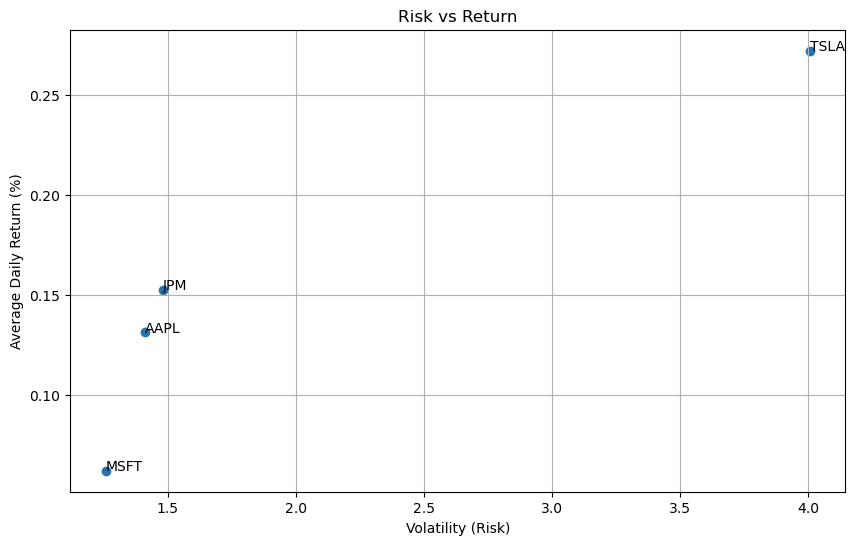

In [41]:
plt.figure(figsize=(10,6))
plt.scatter(volatility, average_returns)

for stock in volatility.index:
    plt.annotate(stock, (volatility[stock], average_returns[stock]))

plt.xlabel("Volatility (Risk)")
plt.ylabel("Average Daily Return (%)")
plt.title("Risk vs Return")
plt.grid(True)
plt.show()

##### The scatter plot illustrates the relationship between return and volatility. This shows potential trade offs between reward and risk when investing in a certain stock

In [33]:
correlation = daily_returns.corr()
correlation

Ticker,AAPL,JPM,MSFT,TSLA
Ticker,,,,
AAPL,1.000000,0.015174,0.470472,0.329608
JPM,0.015174,1.000000,0.160828,0.233340
MSFT,0.470472,0.160828,1.000000,0.301909
TSLA,0.329608,0.233340,0.301909,1.000000


##### Most stocks shown have a moderate to low positive correlations. This shows that price movements are somewhat related but not enough to be considered as directly influential to each other, showing there is some diversification

## Portfolio Analysis

#### This sections creates a portfolio derived of the 4 stocks compared, each with equal weighting. This shows investors the hypothetical returns if there were to have invested in these 4 stocks equally in 2024. The stocks chosen were specfically chosen to be in varying industries, with Apple and Microsoft being in the technology sector (Apple specifically being consumer electronics and Microsoft being software), Tesla being in the clean energy, automotive industry and JP Morgan being in the financial sector - providing the portfolio with diversification and covering numerous sectors

In [34]:
weighting = [0.25, 0.25, 0.25, 0.25]
portfolio_returns = daily_returns.dot(weighting)


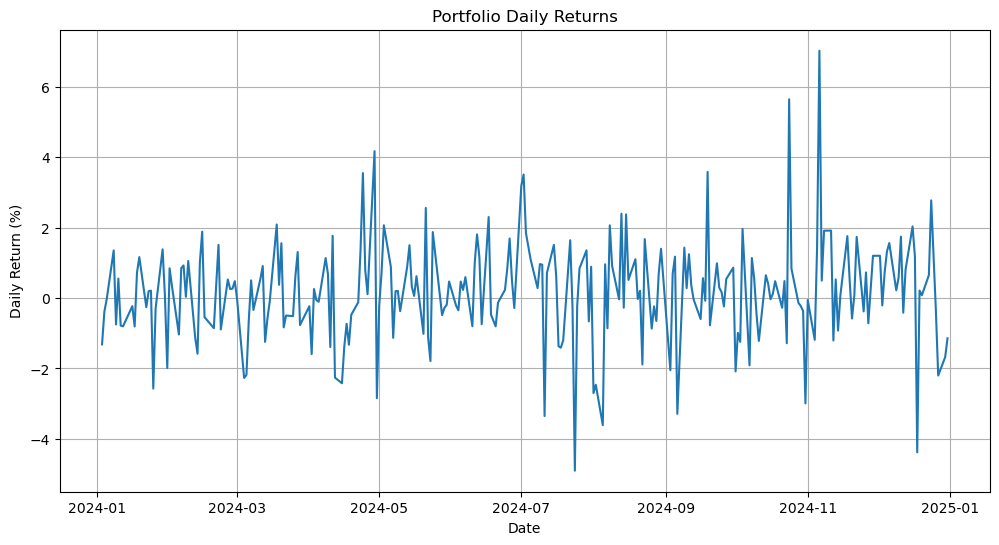

In [35]:
plt.figure(figsize=(12,6))

plt.plot(portfolio_returns)

plt.title("Portfolio Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.grid(True)

plt.show()

#### The portfolio combines numerous companies into a single investment showing how diversifiaction and minimise the impact of a large movement in a singular stock

## Conclusion

#### This project demonstrated how Python (utilising Pands, NumPy and Matplotlib) can be used to analyse historical stock data and compare different companies in different industries through various metrics (such as daily returns, volatility and correlation). These allow an insight into different relationships such as risk vs return of different stocks throughout 2024.
#### Towards the end the project introduced the concept or a portfolio by creating a portfolio compiled of the 4 different companies chosen, each equally weighted. This shows the hypothetical returns on this portfolio throughout 2024, with returns peaking sometime in November and reaching their lowest between July and August. This demonstrates the impact of diverisifation since the companies used were in mutliple sectors.
#### Overall, this project strenghtened my understanding of financial data analysis, how various statistical measures I had previously learnt were applies in real world investment analysis and the application of Python in financial problems. If I were to improve the prpject, I would use a higher number of companies spanning a larger of industries. I would also aim to use more advanced performance metrics which are used in real world porfolio analysis.